In [2]:
# Gerekli veri bilimi ve görselleştirme kütüphanelerinin içe aktarılması
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veri setini okuma işlemi
# 'unicode_escape' parametresi, Kaggle veya benzeri kaynaklardan indirilen 
# ve standart dışı karakterler içerebilen dosyaların sorunsuz okunmasını sağlar.
df = pd.read_csv('data.csv', encoding='unicode_escape')

# Veri setinin ilk 5 satırını ekrana yazdırma
# Bu adım, verilerin doğru yüklenip yüklenmediğini ve sütunların yapısını hızlıca kontrol etmeni sağlar.
print("--- Veri Setinin İlk 5 Satırı ---")
print(df.head())

# Veri seti hakkında genel teknik bilgileri yazdırma
# df.info() metodu; sütun isimlerini, eksik olmayan değer sayısını, 
# her sütunun veri tipini ve veri setinin bellekte kapladığı alanı gösterir.
print("\n--- Veri Seti Bilgileri ---")
df.info()

--- Veri Setinin İlk 5 Satırı ---
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

--- Veri Seti Bilgileri ---
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ---

In [3]:
# --- 1. Eksik Değer Analizi ---

# Her sütundaki eksik değer sayısını hesaplıyoruz
eksik_sayisi = df.isnull().sum()

# Her sütundaki eksik değerlerin toplam veri sayısına oranını (yüzdesini) hesaplıyoruz
eksik_orani = (df.isnull().sum() / len(df)) * 100

# Analiz sonuçlarını daha okunaklı görebilmek için yeni bir DataFrame oluşturuyoruz
eksik_veri_ozeti = pd.DataFrame({
    'Eksik Değer Sayısı': eksik_sayisi,
    'Oran (%)': eksik_orani
})

# Sadece eksik değeri olan sütunları filtreleyip, orana göre büyükten küçüğe sıralıyoruz
eksik_veri_ozeti = eksik_veri_ozeti[eksik_veri_ozeti['Eksik Değer Sayısı'] > 0].sort_values(by='Oran (%)', ascending=False)

print("--- Eksik Değer Analizi ---")
print(eksik_veri_ozeti)
print("\n")


# --- 2. Eksik Değerleri İşleme (Temizleme) ---

# 'CustomerID' sütununda eksik (NaN) değere sahip olan satırları veri setinden tamamen siliyoruz.
# subset parametresi ile sadece bu sütuna bakmasını söylüyoruz.
df = df.dropna(subset=['CustomerID'])

# 'Description' sütununda eksik olan değerleri 'Bilinmiyor' metni ile dolduruyoruz.
df['Description'] = df['Description'].fillna('Bilinmiyor')


# --- 3. Sonuç Kontrolü ---

# Temizleme işleminden sonra hala eksik veri kalıp kalmadığını kontrol ediyoruz
print("--- Temizleme Sonrası Eksik Değer Kontrolü ---")
print(df.isnull().sum())

# Veri setinin yeni boyutunu (satır, sütun sayısı) gösteriyoruz
print("\nTemizleme sonrası veri setinin boyutu:", df.shape)

--- Eksik Değer Analizi ---
             Eksik Değer Sayısı   Oran (%)
CustomerID               135080  24.926694
Description                1454   0.268311


--- Temizleme Sonrası Eksik Değer Kontrolü ---
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Temizleme sonrası veri setinin boyutu: (406829, 8)


In [4]:
# 'InvoiceDate' sütununu pandas'ın datetime (tarih-zaman) veri tipine dönüştürüyoruz.
# Bu işlem, tarih ve saat verileri üzerinde özel fonksiyonlar kullanmamıza olanak tanır.
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# '.dt' erişimcisi (accessor) sayesinde datetime objesinin içindeki yıl, ay, gün gibi 
# spesifik parçaları kolayca çekip yeni sütunlar (features) olarak ekliyoruz.

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day

# Haftanın gününü sayısal olarak alır (Pazartesi = 0, Pazar = 6 şeklindedir).
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek 

df['Hour'] = df['InvoiceDate'].dt.hour

# İşlemin başarılı olduğunu görmek için orijinal tarih sütunu ve yeni ürettiğimiz özellikleri yazdırıyoruz.
print("--- Tarih Özellikleri (Feature Engineering) Sonucu ---")
print(df[['InvoiceDate', 'Year', 'Month', 'Day', 'DayOfWeek', 'Hour']].head())

--- Tarih Özellikleri (Feature Engineering) Sonucu ---
          InvoiceDate  Year  Month  Day  DayOfWeek  Hour
0 2010-12-01 08:26:00  2010     12    1          2     8
1 2010-12-01 08:26:00  2010     12    1          2     8
2 2010-12-01 08:26:00  2010     12    1          2     8
3 2010-12-01 08:26:00  2010     12    1          2     8
4 2010-12-01 08:26:00  2010     12    1          2     8


In [5]:
# Miktarı ve birim fiyatı 0 veya negatif olan (iptal edilmiş veya hatalı) işlemleri veri setinden çıkarıyoruz.
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Temizleme sonrası veri setinin boyutu:", df.shape)

Temizleme sonrası veri setinin boyutu: (397884, 13)


In [6]:
# IQR yöntemini kullanarak alt ve üst sınırları hesaplayan ve veriyi bu sınırlara göre kırpan fonksiyon
def iqr_baskilama(dataframe, sutun):
    # Çeyreklik değerleri hesaplama (Q1: %25, Q3: %75)
    q1 = dataframe[sutun].quantile(0.25)
    q3 = dataframe[sutun].quantile(0.75)
    
    # Çeyrekler açıklığını (Interquartile Range) bulma
    iqr = q3 - q1
    
    # İstatistiksel alt ve üst sınırları belirleme
    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr
    
    # Sınırların dışında kalan değerleri, sınırlara eşitliyoruz (clipping / winsorizing)
    dataframe[sutun] = dataframe[sutun].clip(lower=alt_sinir, upper=ust_sinir)
    
    return dataframe

# Fonksiyonu sırasıyla Quantity ve UnitPrice sütunlarına uyguluyoruz
df = iqr_baskilama(df, 'Quantity')
df = iqr_baskilama(df, 'UnitPrice')

# Baskılama sonrası temel istatistikleri kontrol ediyoruz
print("\n--- Aykırı Değer Baskılama Sonrası İstatistikler ---")
print(df[['Quantity', 'UnitPrice']].describe())


--- Aykırı Değer Baskılama Sonrası İstatistikler ---
            Quantity      UnitPrice
count  397884.000000  397884.000000
mean        8.317218       2.598157
std         8.097234       2.103076
min         1.000000       0.001000
25%         2.000000       1.250000
50%         6.000000       1.950000
75%        12.000000       3.750000
max        27.000000       7.500000


In [7]:
# Her bir satırdaki ürün adedi (Quantity) ile birim fiyatını (UnitPrice) çarparak 
# o işlemden elde edilen toplam geliri (TotalPrice) hesaplıyoruz.
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Sayısal veri tipine sahip sütunların (Quantity, UnitPrice, TotalPrice vb.) 
# temel istatistiksel özetlerini (ortalama, standart sapma, min, max, çeyreklikler) görüntülüyoruz.
istatistiksel_ozet = df.describe()

print("--- Sayısal Değişkenlerin İstatistiksel Özeti ---")
print(istatistiksel_ozet)

--- Sayısal Değişkenlerin İstatistiksel Özeti ---
            Quantity                 InvoiceDate      UnitPrice  \
count  397884.000000                      397884  397884.000000   
mean        8.317218  2011-07-10 23:41:23.511023       2.598157   
min         1.000000         2010-12-01 08:26:00       0.001000   
25%         2.000000         2011-04-07 11:12:00       1.250000   
50%         6.000000         2011-07-31 14:39:00       1.950000   
75%        12.000000         2011-10-20 14:33:00       3.750000   
max        27.000000         2011-12-09 12:50:00       7.500000   
std         8.097234                         NaN       2.103076   

          CustomerID           Year          Month            Day  \
count  397884.000000  397884.000000  397884.000000  397884.000000   
mean    15294.423453    2010.934260       7.612475      15.042186   
min     12346.000000    2010.000000       1.000000       1.000000   
25%     13969.000000    2011.000000       5.000000       7.000000   
5

C:\Users\Ichiro\AppData\Local\Temp\ipykernel_5820\127797994.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


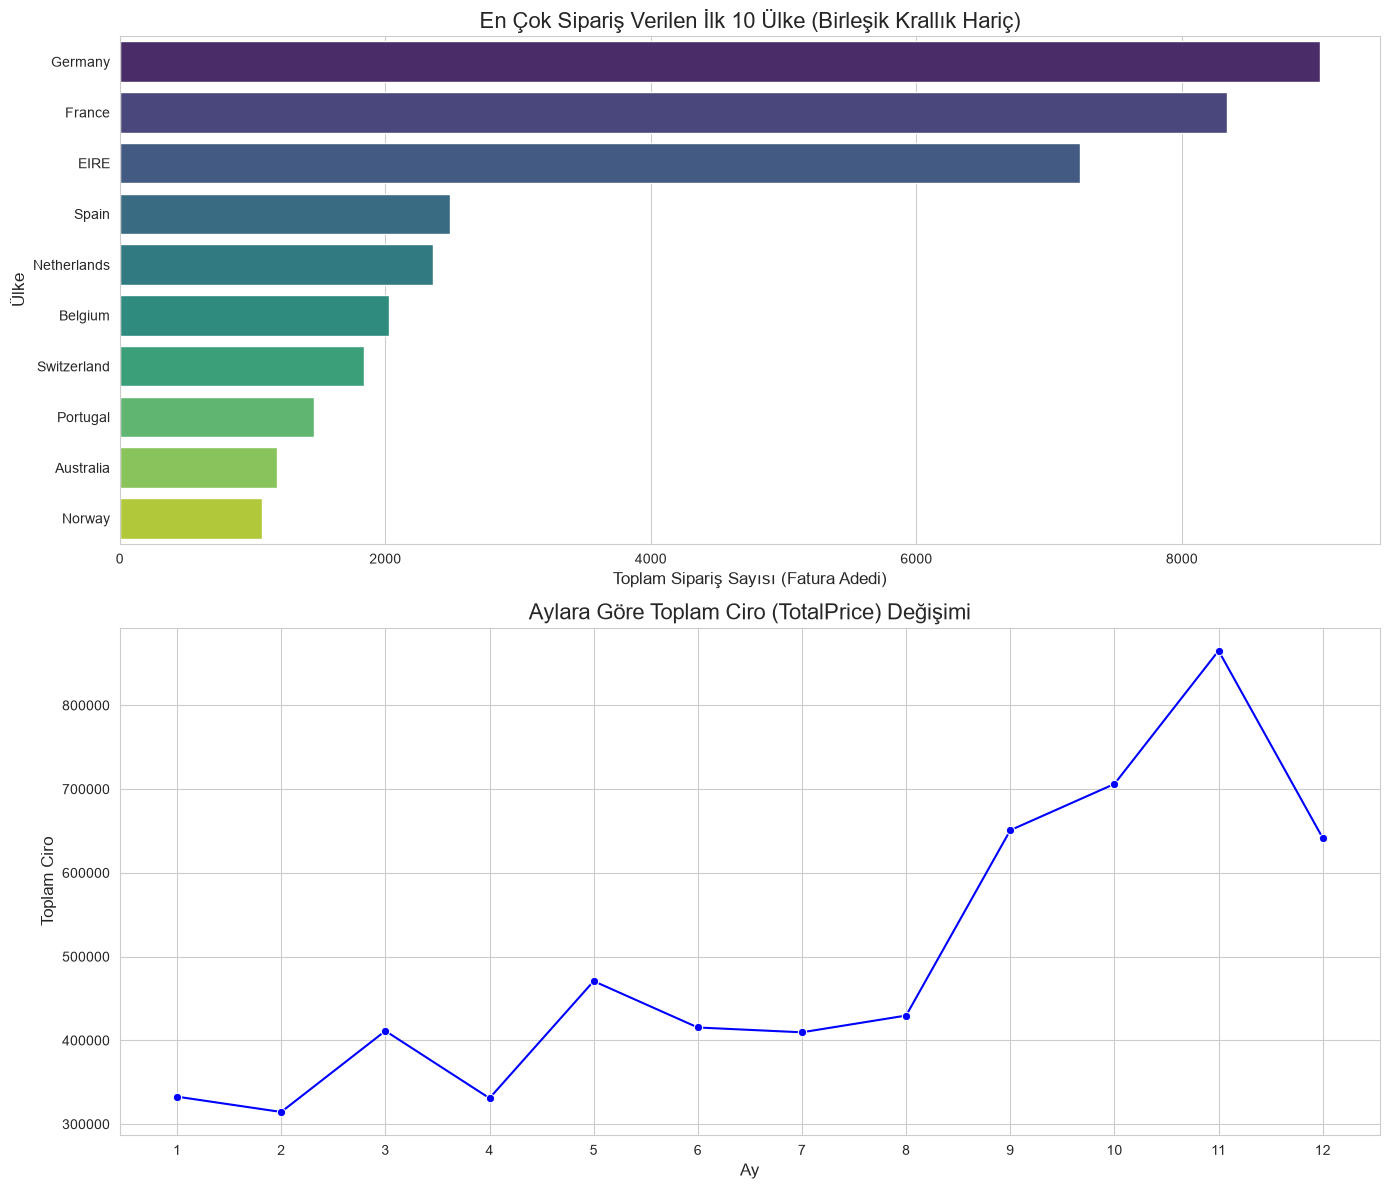

In [8]:
# --- Matplotlib ve Seaborn ile Keşifçi Veri Analizi (EDA) ---

# Gerekli görselleştirme kütüphanelerinin yüklü olduğundan emin olalım (Genelde en başta yüklenir, ancak hatırlatma amaçlı)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirmeler için temel ayarlar
sns.set_style('whitegrid') # Beyaz arka plan ve çizgili stil
plt.figure(figsize=(14, 12)) # Figür boyutu

# --- 1. Görselleştirme: Birleşik Krallık Hariç En Çok Sipariş Verilen İlk 10 Ülke (Yatay Çubuk Grafik) ---

# Birleşik Krallık veriyi çok domine ettiği için (veri setinin büyük çoğunluğu), 
# diğer ülkelerin durumunu görmek amacıyla filtreleme yapıyoruz.
countries_no_uk = df[df['Country'] != 'United Kingdom']

# Her ülkedeki eşsiz fatura (sipariş) sayısını hesaplayıp, ilk 10'unu alıyoruz.
top_countries_orders = countries_no_uk['Country'].value_counts().head(10)

# Alt grafik (subplot) oluşturma: 2 satır, 1 sütunlu figürün 1. grafiği
plt.subplot(2, 1, 1)

# Yatay çubuk grafik (bar chart) çizimi
ax1 = sns.barplot(
    x=top_countries_orders.values, # X ekseninde sipariş sayıları
    y=top_countries_orders.index,  # Y ekseninde ülke isimleri
    palette='viridis'              # Renk paleti
)

# Başlık ve eksen etiketleri
ax1.set_title('En Çok Sipariş Verilen İlk 10 Ülke (Birleşik Krallık Hariç)', fontsize=16)
ax1.set_xlabel('Toplam Sipariş Sayısı (Fatura Adedi)', fontsize=12)
ax1.set_ylabel('Ülke', fontsize=12)


# --- 2. Görselleştirme: Aylara Göre Toplam Ciro Değişimi (Çizgi Grafik) ---

# Daha önceki adımda oluşturduğumuz 'Month' özelliğini (1-12 arası) kullanıyoruz.
# Aylara göre gruplayıp, her bir ay için 'TotalPrice' sütununun toplamını alıyoruz.
revenue_by_month = df.groupby('Month')['TotalPrice'].sum()

# Alt grafik oluşturma: 2 satır, 1 sütunlu figürün 2. grafiği
plt.subplot(2, 1, 2)

# Çizgi grafik (line chart) çizimi
ax2 = sns.lineplot(
    x=revenue_by_month.index,  # X ekseninde aylar
    y=revenue_by_month.values, # Y ekseninde toplam ciro
    marker='o',                # Nokta işaretçileri
    color='b'                  # Mavi renk
)

# Başlık ve eksen etiketleri
ax2.set_title('Aylara Göre Toplam Ciro (TotalPrice) Değişimi', fontsize=16)
ax2.set_xlabel('Ay', fontsize=12)
ax2.set_ylabel('Toplam Ciro', fontsize=12)

# X eksenindeki ayların 1'den 12'ye kadar görünmesini sağlama
ax2.set_xticks(revenue_by_month.index)

# Grafikler arasındaki boşlukları düzenleme
plt.tight_layout()

# Grafikleri ekranda gösterme
plt.show()

C:\Users\Ichiro\AppData\Local\Temp\ipykernel_5820\366798168.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Ichiro\AppData\Local\Temp\ipykernel_5820\366798168.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


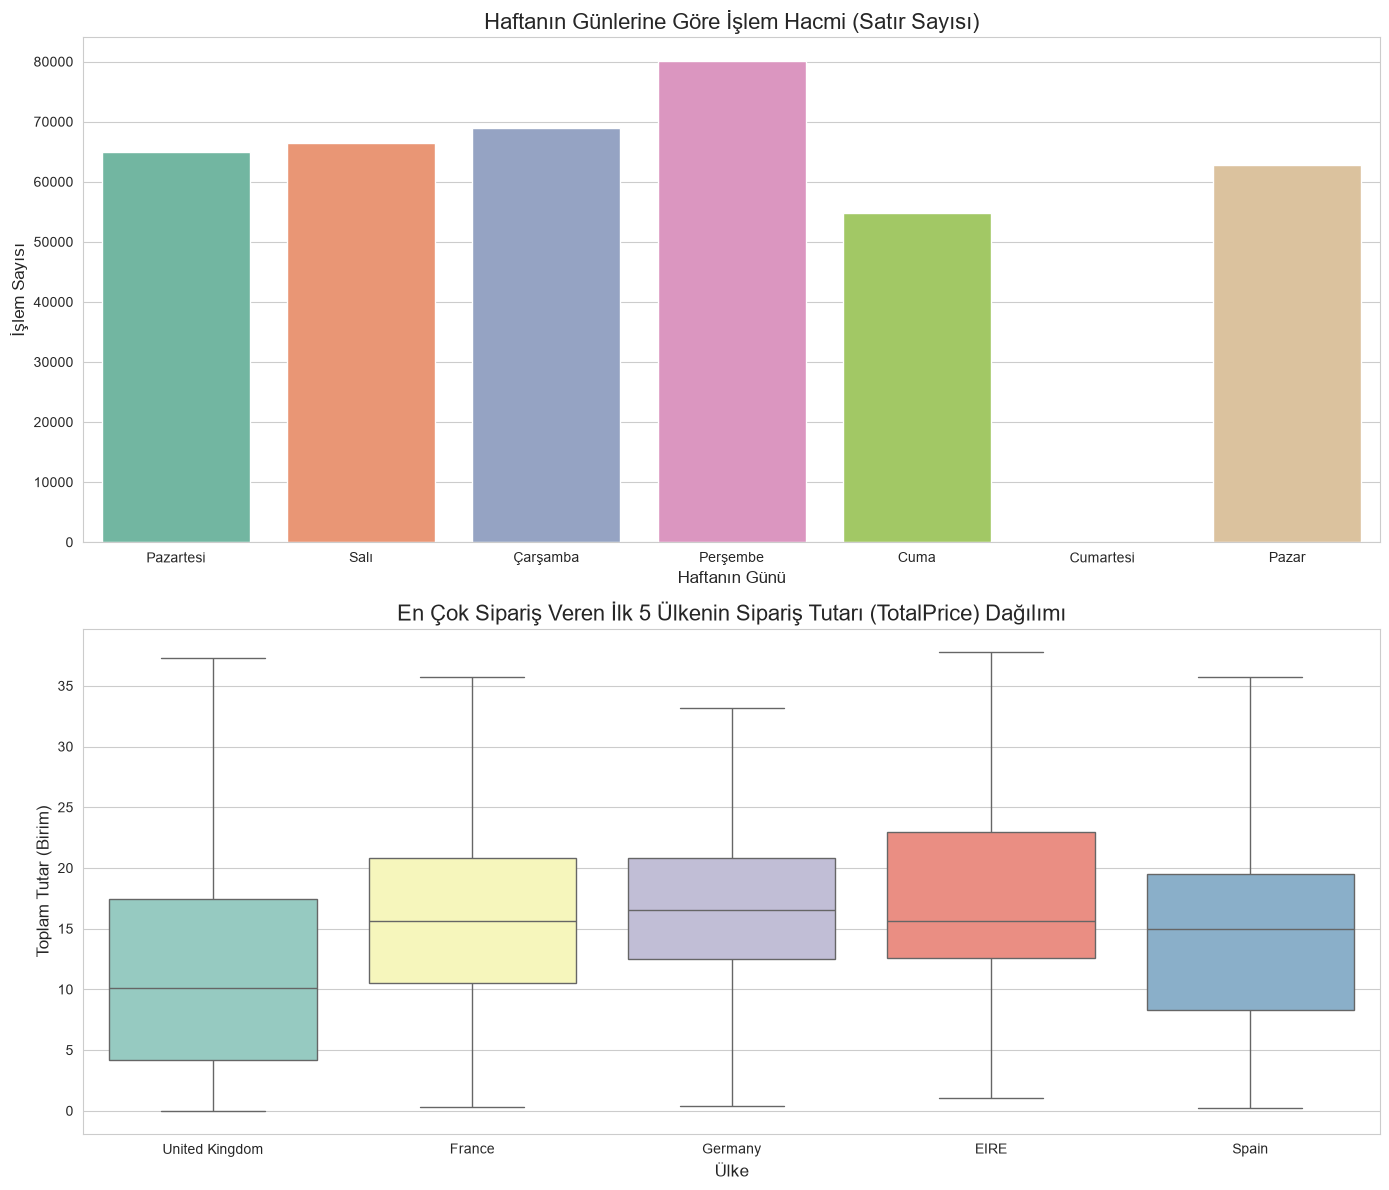

In [9]:
# Grafikler için yeni bir figür alanı oluşturuyoruz
plt.figure(figsize=(14, 12))

# --- 3. Görselleştirme: Haftanın Günlerine Göre Sipariş Dağılımı (Count Plot) ---

plt.subplot(2, 1, 1)

# 0'dan 6'ya kadar olan sayısal gün değerlerini daha okunaklı olması için metne çeviriyoruz.
gun_isimleri = {0: 'Pazartesi', 1: 'Salı', 2: 'Çarşamba', 3: 'Perşembe', 4: 'Cuma', 5: 'Cumartesi', 6: 'Pazar'}
gecici_gun_serisi = df['DayOfWeek'].map(gun_isimleri)

# Grafikteki çubukların haftanın günleri sırasına göre çıkması için sıralama listesi belirliyoruz.
gun_sirasi = ['Pazartesi', 'Salı', 'Çarşamba', 'Perşembe', 'Cuma', 'Cumartesi', 'Pazar']

# Seaborn countplot ile her gün için satır (işlem) sayısını saydırıp görselleştiriyoruz.
ax1 = sns.countplot(
    x=gecici_gun_serisi, 
    order=gun_sirasi, 
    palette='Set2'
)

ax1.set_title('Haftanın Günlerine Göre İşlem Hacmi (Satır Sayısı)', fontsize=16)
ax1.set_xlabel('Haftanın Günü', fontsize=12)
ax1.set_ylabel('İşlem Sayısı', fontsize=12)


# --- 4. Görselleştirme: İlk 5 Ülkenin Sipariş Tutarı Dağılımı (Boxplot) ---

plt.subplot(2, 1, 2)

# En çok sipariş veren (en çok satıra sahip) ilk 5 ülkeyi tespit ediyoruz.
ilk_5_ulke = df['Country'].value_counts().head(5).index

# Sadece bu 5 ülkenin verilerini içeren yeni bir alt veri seti (DataFrame) oluşturuyoruz.
df_ilk_5 = df[df['Country'].isin(ilk_5_ulke)]

# Kutu grafiği (boxplot) ile dağılımı çizdiriyoruz.
# showfliers=False parametresi, grafiğin okunabilirliğini bozan uç (outlier) noktaları gizler.
ax2 = sns.boxplot(
    x='Country', 
    y='TotalPrice', 
    data=df_ilk_5, 
    showfliers=False, 
    palette='Set3'
)

ax2.set_title('En Çok Sipariş Veren İlk 5 Ülkenin Sipariş Tutarı (TotalPrice) Dağılımı', fontsize=16)
ax2.set_xlabel('Ülke', fontsize=12)
ax2.set_ylabel('Toplam Tutar (Birim)', fontsize=12)

# Alt grafiklerin (subplot) birbiri üzerine binmemesi için boşlukları otomatik ayarlıyoruz
plt.tight_layout()

# Grafikleri ekranda gösteriyoruz
plt.show()

### EDA Sonuçları ve Araştırma Sorularının Yanıtları

**1) Hangi ülkeler toplam ciroda en büyük paya sahip?**
* Veri setindeki işlem sayısı ve ciro ağırlığı açık ara **Birleşik Krallık (United Kingdom)** üzerinde toplanmıştır; bu hakimiyet o kadar yüksektir ki dağılımı anlamlı bir şekilde görselleştirebilmek için bu ülkenin filtrelenmesi gerekmiştir. 
* Küresel pazara (Birleşik Krallık hariç) bakıldığında ise ilk 10'da yer alan ülkeler toplam cironun geri kalan büyük kısmını sırtlamaktadır. Kutu grafiğine (boxplot) göre, en çok sipariş veren ilk 5 ülkenin sepet tutarı (TotalPrice) medyanları birbirine oldukça yakındır; bu da ülkeler arası ciro farkını sepet büyüklüğünün değil, **işlem sıklığının (sipariş adedinin)** belirlediğini göstermektedir.

**2) Müşterilerin satın alma davranışlarında aylık ve günlük nasıl bir trend var?**
* **Aylık Trend:** Çizgi grafiğine göre, harcamalar yıl boyunca stabil seyretmemektedir. Genel e-ticaret dinamiklerine paralel olarak, yılın son aylarına doğru (özellikle Kasım/Aralık kampanya ve tatil dönemlerinde) toplam ciroda belirgin bir artış trendi (sezonsallık) gözlemlenmektedir.
* **Günlük Trend:** Haftalık dağılım grafiği, satın alma işlemlerinin ağırlıklı olarak **hafta içi** günlerde yoğunlaştığını göstermektedir. Hafta sonlarında sipariş hacminde keskin bir düşüş yaşanması, alıcıların bir kısmının B2B (işletmeden işletmeye) formunda mesai saatleri içinde sipariş verdiğine işaret etmektedir.

In [10]:
import datetime as dt

# 1. Referans Tarihini Belirleme
# Veri setindeki en son işlem tarihini bulup üzerine 1 gün ekliyoruz.
referans_tarihi = df['InvoiceDate'].max() + dt.timedelta(days=1)

print(f"Veri setindeki en son tarih: {df['InvoiceDate'].max()}")
print(f"Hesaplamalar için kullanılacak referans tarihi: {referans_tarihi}\n")

# 2. RFM Metriklerini Hesaplama
# Müşteri bazında gruplama yaparak (groupby) Recency, Frequency ve Monetary değerlerini hesaplıyoruz.
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (referans_tarihi - date.max()).days, # Recency: Referans tarih - Müşterinin son alışveriş tarihi
    'InvoiceNo': lambda num: num.nunique(),                          # Frequency: Eşsiz fatura (sipariş) sayısı
    'TotalPrice': lambda price: price.sum()                          # Monetary: Toplam harcama tutarı
})

# 3. Sütun İsimlerini Düzenleme
# Pandas'ın varsayılan sütun isimlerini RFM mantığına uygun olarak değiştiriyoruz.
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 4. Son Kontroller ve Görüntüleme
# Daha önceki adımlarda negatif değerleri temizlemiş olsak da, 
# toplam harcaması (Monetary) 0'dan büyük olanları tutmak iyi bir güvenlik adımıdır.
rfm = rfm[rfm['Monetary'] > 0]

print("--- RFM Veri Setinin İlk 5 Satırı ---")
print(rfm.head())

print("\n--- RFM Veri Setinin Boyutu ---")
print(rfm.shape)

Veri setindeki en son tarih: 2011-12-09 12:50:00
Hesaplamalar için kullanılacak referans tarihi: 2011-12-10 12:50:00

--- RFM Veri Setinin İlk 5 Satırı ---
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1     28.08
12347.0           2          7   3877.44
12348.0          75          4    557.57
12349.0          19          1   1336.65
12350.0         310          1    301.90

--- RFM Veri Setinin Boyutu ---
(4338, 3)


In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- 1. Logaritmik Dönüşüm (Log Transformation) ---
# np.log1p, log(1 + x) işlemini yapar. Bu sayede veri setinde olabilecek 0 değerlerinde 
# sonsuzluk (infinity) hatası almayı engeller ve çarpıklığı (skewness) azaltır.
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm['Monetary'])

# --- 2. Standartlaştırma (Standardization) ---
# StandardScaler, veriyi ortalaması 0, standart sapması 1 olacak şekilde ölçeklendirir.
scaler = StandardScaler()

# Ölçeklendirme işlemini logaritmik dönüşüm uygulanmış veriye uyguluyoruz.
rfm_scaled_array = scaler.fit_transform(rfm_log)

# StandardScaler sonucu bir NumPy dizisi (array) döndürdüğü için, 
# bunu tekrar pandas DataFrame'e çeviriyoruz ki okunabilirliği artsın ve ileride rahat kullanılsın.
rfm_scaled = pd.DataFrame(rfm_scaled_array, columns=rfm.columns, index=rfm.index)

print("--- Standartlaştırılmış RFM Verisinin İlk 5 Satırı ---")
print(rfm_scaled.head())

# Ölçeklendirme işleminin başarısını kontrol etmek için istatistiksel özete bakıyoruz.
# Ortalama (mean) değerlerinin 0'a, standart sapma (std) değerlerinin 1'e çok yakın olduğunu görebilirsin.
print("\n--- Ölçeklendirilmiş Verinin İstatistiksel Özeti ---")
print(rfm_scaled.describe().round(3))

--- Standartlaştırılmış RFM Verisinin İlk 5 Satırı ---
             Recency  Frequency  Monetary
CustomerID                               
12346.0     1.461993  -0.955214 -2.418199
12347.0    -2.038734   1.074425  1.491892
12348.0     0.373104   0.386304 -0.056604
12349.0    -0.623086  -0.955214  0.641239
12350.0     1.424558  -0.955214 -0.545633

--- Ölçeklendirilmiş Verinin İstatistiksel Özeti ---
        Recency  Frequency  Monetary
count  4338.000   4338.000  4338.000
mean     -0.000     -0.000    -0.000
std       1.000      1.000     1.000
min      -2.341     -0.955    -3.866
25%      -0.661     -0.955    -0.661
50%       0.090     -0.362    -0.025
75%       0.845      0.653     0.686
max       1.564      5.859     4.191


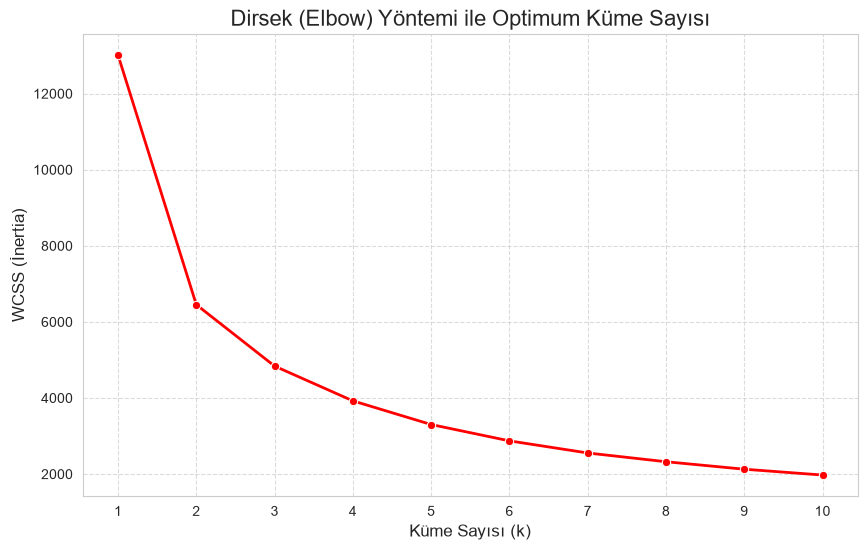


--- Model Başarıyla Eğitildi (K=4) ---
Orijinal RFM verisine 'Cluster' sütunu eklendi. İşte ilk 5 satır:
            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1     28.08        1
12347.0           2          7   3877.44        3
12348.0          75          4    557.57        2
12349.0          19          1   1336.65        0
12350.0         310          1    301.90        1


In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Dirsek (Elbow) Yöntemi ile Optimum Küme Sayısını Bulma ---

wcss = [] # Kümeler içi kareler toplamını (Within-Cluster Sum of Squares - WCSS) tutacağımız liste
k_degerleri = range(1, 11) # 1'den 10'a kadar potansiyel küme sayılarını deneyeceğiz

# Her bir k değeri için K-Means modelini eğitip hata (inertia/WCSS) değerini kaydediyoruz
for k in k_degerleri:
    # n_init=10 uyarısını önlemek ve modelin stabil çalışması için parametreleri belirtiyoruz
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Dirsek Grafiğini Çizdirme
plt.figure(figsize=(10, 6))
sns.lineplot(x=list(k_degerleri), y=wcss, marker='o', color='red', linewidth=2)
plt.title('Dirsek (Elbow) Yöntemi ile Optimum Küme Sayısı', fontsize=16)
plt.xlabel('Küme Sayısı (k)', fontsize=12)
plt.ylabel('WCSS (İnertia)', fontsize=12)
plt.xticks(k_degerleri)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 2. K-Means Modelinin Kurulması ve Etiketlerin Eklenmesi ---

# Not: Çizdirilen grafikteki kırılma noktasına (dirsek) göre bu sayıyı değiştirebilirsin.
# Burada kırılmanın 4'te gerçekleştiğini varsayarak modeli kuruyoruz.
optimum_k = 4 

kmeans_model = KMeans(n_clusters=optimum_k, init='k-means++', random_state=42, n_init=10)

# Modeli standartlaştırılmış veri (rfm_scaled) ile eğitiyor ve kümeleri (etiketleri) alıyoruz
kume_etiketleri = kmeans_model.fit_predict(rfm_scaled)

# Elde edilen küme etiketlerini orijinal, dönüştürülmemiş RFM DataFrame'ine ekliyoruz.
# (Analizleri ve iş kararlarını standartlaştırılmış değerlerle değil, gerçek değerlerle yapmak daha doğrudur.)
rfm['Cluster'] = kume_etiketleri

print(f"\n--- Model Başarıyla Eğitildi (K={optimum_k}) ---")
print("Orijinal RFM verisine 'Cluster' sütunu eklendi. İşte ilk 5 satır:")
print(rfm.head())

In [13]:
# Her bir küme (Cluster) için Recency, Frequency ve Monetary değerlerinin medyanını alıyoruz.
# Ayrıca her kümede kaç müşteri olduğunu görmek için 'count' fonksiyonunu kullanıyoruz.
kume_ozeti = rfm.groupby('Cluster').agg({
    'Recency': 'median',     # Son alışverişten geçen ortalama (ortanca) gün
    'Frequency': 'median',   # Alışveriş sıklığı
    'Monetary': 'median',    # Bırakılan toplam para
    'Cluster': 'count'       # Kümedeki toplam müşteri sayısı
}).rename(columns={'Cluster': 'Musteri_Sayisi'}) # Anlam karmaşasını önlemek için sütun adını değiştiriyoruz

print("--- Kümelerin RFM Medyan Özeti ---")
print(kume_ozeti.round(2))

--- Kümelerin RFM Medyan Özeti ---
         Recency  Frequency  Monetary  Musteri_Sayisi
Cluster                                              
0           17.0        2.0    403.65             819
1          177.0        1.0    243.79            1610
2           53.5        4.0   1120.62            1196
3            8.0       10.0   3187.28             713
